# SimCLR : Batch Size Ablation

We study the impact of the **batch size** on SimCLR.

We keep **everything identical** and vary **only the batch size**: `[128, 256, 512]`.

The learning rate is **scaled linearly** with the batch size (`lr = base_lr * batch / 256`), so that large batches are not penalised by an under-tuned step size.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "DATA"))
CKPT_DIR = './checkpoints/simclr_batch_ablation'
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")
print(f"DATA_DIR = {DATA_DIR}")

device = cuda
DATA_DIR = c:\Users\hugop\Desktop\JEPA\DATA


## 0. Dataset

STL-10 unlabeled for self-supervised pre-training (two augmented views per image), CIFAR-10 for the linear probe. Loaders are created **inside the ablation loop** because the batch size changes.

In [2]:
IMG_SIZE = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)


class TwoViews:
    def __init__(self, transform):
        self.transform = transform
    def __call__(self, x):
        return self.transform(x), self.transform(x)


color_jitter = transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
ssl_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([color_jitter], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
train_probe_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

pretrain_set = torchvision.datasets.STL10(root=DATA_DIR, split='unlabeled', download=True,
                                           transform=TwoViews(ssl_aug))
probe_train  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_probe_tf)
probe_test   = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tf)

CHANNELS    = 3
NUM_CLASSES = len(probe_train.classes)
print(f"pretrain {len(pretrain_set)} | probe train {len(probe_train)} | probe test {len(probe_test)}")

pretrain 100000 | probe train 50000 | probe test 10000


## 1. Architecture

In [3]:
PATCH_SIZE = 4
D_MODEL    = 128
NUM_HEADS  = 4
NUM_LAYERS = 6
D_FF       = 4 * D_MODEL
DROPOUT    = 0.1
PROJ_DIM   = 128
TEMPERATURE = 0.5


def patchify(images, patch_size):
    B, C, H, W = images.shape
    P = patch_size
    x = images.reshape(B, C, H // P, P, W // P, P)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // P) * (W // P), P * P * C)
    return x


class ViTEncoder(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, channels=CHANNELS, d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,d_ff=D_FF, dropout=DROPOUT):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size ** 2 * channels
        self.patch_size = patch_size
        self.projection    = nn.Linear(patch_dim, d_model)
        self.cls_token     = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embedding = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)
        self.dropout       = nn.Dropout(dropout)
        block = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=d_ff,dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, images):
        B = images.shape[0]
        x = patchify(images, self.patch_size)
        x = self.projection(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embedding
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.norm(x)
        return x[:, 0, :]


class ProjectionHead(nn.Module):
    def __init__(self, in_dim=D_MODEL, hidden=D_MODEL*2, out_dim=PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim))
    def forward(self, h):
        return self.net(h)


class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ViTEncoder()
        self.proj    = ProjectionHead()
    def forward(self, x):
        h = self.encoder(x)
        z = F.normalize(self.proj(h), dim=-1)
        return h, z


def nt_xent(z1, z2, tau=TEMPERATURE):
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)
    sim = (z @ z.T) / tau
    sim = sim.masked_fill(torch.eye(2*B, device=z.device, dtype=torch.bool), float('-inf'))
    labels = torch.cat([torch.arange(B, 2*B), torch.arange(0, B)]).to(z.device)
    return F.cross_entropy(sim, labels)

## 2. Training helpers + linear probe

In [4]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


class LinearProbe(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(D_MODEL, num_classes)
        for p in self.encoder.parameters():
            p.requires_grad = False
    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)
        return self.head(h)

## Ablation loop

For each batch size: pre-train SimCLR for 20 epochs (LR scaled linearly), then train a linear
probe for up to 60 epochs with early stopping, and record the best probe test accuracy.

In [5]:
BATCH_SIZES     = [128, 256, 512]
PRETRAIN_EPOCHS = 20
PROBE_EPOCHS    = 60
PATIENCE        = 8
BASE_LR_AT_256  = 6e-4   

results = {}        
pretrain_curves = {}  
for bs in BATCH_SIZES:
    print("=" * 60)
    print(f"BATCH SIZE = {bs}")
    print("=" * 60)
    lr = BASE_LR_AT_256 * bs / 256
    print(f"scaled pretrain lr = {lr:.2e} | negatives per pair = {2*bs - 2}")

    pretrain_loader = DataLoader(pretrain_set, batch_size=bs, shuffle=True,num_workers=0, drop_last=True)

    torch.manual_seed(42)
    simclr = SimCLR().to(device)
    optimizer = torch.optim.AdamW(simclr.parameters(), lr=lr, weight_decay=1e-4)
    losses = []
    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        simclr.train()
        total, n = 0.0, 0
        for (v1, v2), _ in pretrain_loader:
            v1, v2 = v1.to(device), v2.to(device)
            _, z1 = simclr(v1)
            _, z2 = simclr(v2)
            loss = nt_xent(z1, z2)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * v1.size(0); n += v1.size(0)
        avg = total / n
        losses.append(avg)
        print(f"  pretrain {epoch:2d}/{PRETRAIN_EPOCHS} | NT-Xent {avg:.4f}")
    pretrain_curves[bs] = losses
    torch.save({'model': simclr.state_dict(), 'losses': losses, 'batch_size': bs},
               os.path.join(CKPT_DIR, f'simclr_bs{bs}.pt'))

    probe_train_loader = DataLoader(probe_train, batch_size=128, shuffle=True,  num_workers=0)
    probe_test_loader  = DataLoader(probe_test,  batch_size=128, shuffle=False, num_workers=0)
    probe = LinearProbe(simclr.encoder, NUM_CLASSES).to(device)
    p_opt = torch.optim.AdamW(probe.head.parameters(), lr=1e-3, weight_decay=0.0)
    criterion = nn.CrossEntropyLoss()
    test_accs = []
    best_acc = 0.0
    for epoch in range(1, PROBE_EPOCHS + 1):
        probe.train(); probe.encoder.eval()
        train_one_epoch(probe, probe_train_loader, p_opt, criterion)
        _, te_acc = evaluate(probe, probe_test_loader, criterion)
        test_accs.append(te_acc)
        best_acc = max(best_acc, te_acc)
        best_epoch = test_accs.index(max(test_accs))
        if (len(test_accs) - 1 - best_epoch) >= PATIENCE:
            break
    results[bs] = best_acc * 100
    print(f"  -> best linear-probe test accuracy = {best_acc*100:.2f}% (epoch {best_epoch+1})")

print("=" * 60)
print("SUMMARY")
for bs in BATCH_SIZES:
    print(f"  batch {bs:5d} | negatives {2*bs-2:5d} | probe acc {results[bs]:.2f}%")

BATCH SIZE = 128
scaled pretrain lr = 3.00e-04 | negatives per pair = 254


C:\Users\hugop\AppData\Local\Temp\ipykernel_6268\1538855589.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)


  pretrain  1/20 | NT-Xent 4.5110
  pretrain  2/20 | NT-Xent 4.3207
  pretrain  3/20 | NT-Xent 4.2612
  pretrain  4/20 | NT-Xent 4.2236
  pretrain  5/20 | NT-Xent 4.1981
  pretrain  6/20 | NT-Xent 4.1778
  pretrain  7/20 | NT-Xent 4.1608
  pretrain  8/20 | NT-Xent 4.1456
  pretrain  9/20 | NT-Xent 4.1310
  pretrain 10/20 | NT-Xent 4.1218
  pretrain 11/20 | NT-Xent 4.1126
  pretrain 12/20 | NT-Xent 4.1034
  pretrain 13/20 | NT-Xent 4.0971
  pretrain 14/20 | NT-Xent 4.0894
  pretrain 15/20 | NT-Xent 4.0859
  pretrain 16/20 | NT-Xent 4.0794
  pretrain 17/20 | NT-Xent 4.0743
  pretrain 18/20 | NT-Xent 4.0694
  pretrain 19/20 | NT-Xent 4.0677
  pretrain 20/20 | NT-Xent 4.0637
  -> best linear-probe test accuracy = 59.24% (epoch 26)
BATCH SIZE = 256
scaled pretrain lr = 6.00e-04 | negatives per pair = 510
  pretrain  1/20 | NT-Xent 5.2136
  pretrain  2/20 | NT-Xent 5.0240
  pretrain  3/20 | NT-Xent 4.9637
  pretrain  4/20 | NT-Xent 4.9299
  pretrain  5/20 | NT-Xent 4.9012
  pretrain  6/20 | 

## Results : probe accuracy vs batch size

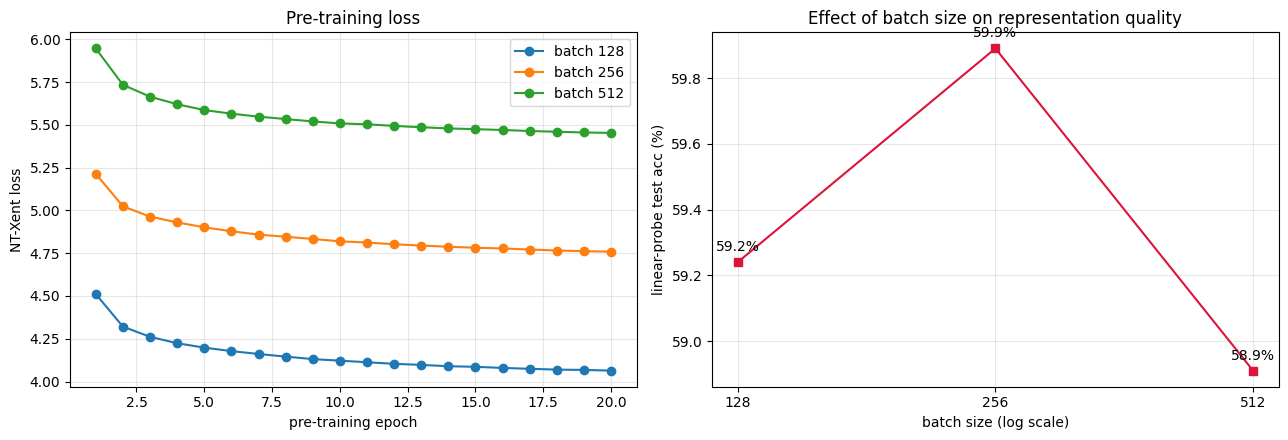

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for bs in BATCH_SIZES:
    ax1.plot(range(1, len(pretrain_curves[bs]) + 1), pretrain_curves[bs], marker='o', label=f'batch {bs}')
ax1.set_xlabel('pre-training epoch'); ax1.set_ylabel('NT-Xent loss')
ax1.set_title('Pre-training loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

xs = BATCH_SIZES
ys = [results[bs] for bs in BATCH_SIZES]
ax2.plot(xs, ys, marker='s', color='crimson')
for x, y in zip(xs, ys):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
ax2.set_xscale('log', base=2); ax2.set_xticks(xs); ax2.set_xticklabels(xs)
ax2.set_xlabel('batch size (log scale)'); ax2.set_ylabel('linear-probe test acc (%)')
ax2.set_title('Effect of batch size on representation quality'); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()